In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import warnings

warnings.filterwarnings("ignore")

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import ElasticNetCV
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, RandomizedSearchCV

# from utils.utils import *
from utils.data_loader import load_data

# Loading data

In [2]:
final_clean_strained = load_data(db_level=0)

In [3]:
peak_curvs = final_clean_strained["PeakI Curvature"].apply(pd.Series)
peak_curvs.columns = [
    "PeakI Left Curvature",
    "PeakI Overall Curvature",
    "PeakI Right Curvature",
]
trough_curvs = final_clean_strained["TroughI Curvature"].apply(pd.Series)
trough_curvs.columns = [
    "TroughI Left Curvature",
    "TroughI Overall Curvature",
    "TroughI Right Curvature",
]
final_clean_strained = pd.concat(
    [final_clean_strained, peak_curvs, trough_curvs], axis=1
)
final_clean_strained["Noise"] = [
    0 if x else 1 for x in (final_clean_strained["Noise"] <= 0.91)
]

In [4]:
final_clean_strained = (
    final_clean_strained.groupby(["Subject", "Frequency(kHz)", "Level(dB)"])
    .agg(
        {
            "Amplitude": "mean",
            "SynapsesPerIHC": "mean",
            "IHCs": "mean",
            "OrphansPerIHC": "mean",
            "Waveform": "first",
            "WaveI": "first",
            "Peaks": "first",
            "Troughs": "first",
            "Strain": "first",
            "Sex": "first",
            "Group": "first",
            "Noise": "mean",
            "Time (str)": "first",
            "Time (hrs)": "first",
            "Strain (binary)": "first",
            "PeakI Left Curvature": "first",
            "PeakI Overall Curvature": "first",
            "PeakI Right Curvature": "first",
            "TroughI Left Curvature": "first",
            "TroughI Overall Curvature": "first",
            "TroughI Right Curvature": "first",
            "Slope": "first",
            "Distance": "first",
            "Total Variance": "first",
        }
    )
    .reset_index()
)

In [5]:
def split_by_mouse(
    data,
    split_on="Subject",
    stratify_on="Group",
    test_size=0.2,
    val_size=0.18,
    random_state=22,
    return_idx=False,
):
    mice = data[[split_on, stratify_on]].drop_duplicates().set_index(split_on)

    train, test = train_test_split(
        mice.index,
        test_size=test_size,
        shuffle=True,
        stratify=mice[stratify_on],
        random_state=random_state,
    )

    train_indices = data[split_on].isin(train)
    test_indices = data[split_on].isin(test)

    train2, val = train_test_split(
        train,
        test_size=val_size,
        shuffle=True,
        stratify=mice.loc[train]["Group"],
        random_state=random_state,
    )

    train2_indices = data[split_on].isin(train2)
    val_indices = data[split_on].isin(val)

    data["DataGroup"] = ""
    data.loc[train2_indices, "DataGroup"] = "Train"
    data.loc[val_indices, "DataGroup"] = "Validate"
    data.loc[test_indices, "DataGroup"] = "Test"
    if return_idx:
        return data, train_indices, train2_indices, val_indices, test_indices
    return data

# Train test split

In [6]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
    FunctionTransformer,
    MinMaxScaler,
)


def RF_data_prep(
    data,
    num_features,
    cat_features,
    log_features,
    minmax_features,
    target="SynapsesPerIHC",
):
    X = data[num_features + cat_features + log_features + minmax_features]
    y = data[target]

    X_train, X_test, y_train, y_test = (
        X[data.DataGroup != "Test"],
        X[data.DataGroup == "Test"],
        y[data.DataGroup != "Test"],
        y[data.DataGroup == "Test"],
    )

    log_scale_pipeline = Pipeline(
        [
            ("log_transform", FunctionTransformer(np.log1p, validate=True)),
            ("scaler", StandardScaler()),
        ]
    )

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), num_features),
            ("cat", OneHotEncoder(drop="first", sparse_output=False), cat_features),
            ("log_transform", log_scale_pipeline, log_features),
            ("minmax_scale", MinMaxScaler(), minmax_features),
        ]
    )

    return X_train, X_test, y_train, y_test, preprocessor

In [7]:
final_clean_strained_70 = final_clean_strained[final_clean_strained["Level(dB)"] == 70]
final_clean_strained_70 = split_by_mouse(final_clean_strained_70)
num_features = ["Amplitude", "Slope", "Distance", "Level(dB)"]
cat_features = ["Noise", "Strain (binary)"]
log_features = [
    "Frequency(kHz)",
    "Total Variance",
    "PeakI Left Curvature",
    "PeakI Overall Curvature",
    "PeakI Right Curvature",
    "TroughI Left Curvature",
    "TroughI Overall Curvature",
    "TroughI Right Curvature",
]
minmax_features = ["Time (hrs)"]
X_train, X_test, y_train, y_test, preprocessor = RF_data_prep(
    final_clean_strained_70, num_features, cat_features, log_features, minmax_features
)

# Vanilla Linear Regression

In [8]:
final_clean_strained_70.columns

Index(['Subject', 'Frequency(kHz)', 'Level(dB)', 'Amplitude', 'SynapsesPerIHC',
       'IHCs', 'OrphansPerIHC', 'Waveform', 'WaveI', 'Peaks', 'Troughs',
       'Strain', 'Sex', 'Group', 'Noise', 'Time (str)', 'Time (hrs)',
       'Strain (binary)', 'PeakI Left Curvature', 'PeakI Overall Curvature',
       'PeakI Right Curvature', 'TroughI Left Curvature',
       'TroughI Overall Curvature', 'TroughI Right Curvature', 'Slope',
       'Distance', 'Total Variance', 'DataGroup'],
      dtype='object')

In [9]:
smf_df = final_clean_strained_70.copy()
smf_df.columns = [
    "Subject",
    "Frequency",
    "Level",
    "Amplitude",
    "SynapsesPerIHC",
    "IHCs",
    "OrphansPerIHC",
    "Waveform",
    "WaveI",
    "Peaks",
    "Troughs",
    "Strain",
    "Sex",
    "Group",
    "Noise",
    "Time(str)",
    "Time_hrs",
    "Strain_b",
    "PeakILeftCurvature",
    "PeakIOverallCurvature",
    "PeakIRightCurvature",
    "TroughILeftCurvature",
    "TroughIOverallCurvature",
    "TroughIRightCurvature",
    "Slope",
    "Distance",
    "TotalVariance",
    "DataGroup",
]

In [10]:
import statsmodels.formula.api as smf


def VIF(reg: str):
    vif_model = smf.ols(reg, data=smf_df).fit()
    r2j = vif_model.rsquared
    vif_j = 1 / (1 - r2j)
    return vif_j


features = [
    "Frequency",
    "Amplitude",
    "Slope",
    "TotalVariance",
    "Distance",
    "Noise",
    "Time_hrs",
    "PeakILeftCurvature",
    "PeakIOverallCurvature",
    "PeakIRightCurvature",
    "TroughILeftCurvature",
    "TroughIOverallCurvature",
    "TroughIRightCurvature",
]

for feature in features:
    reg = f"{feature} ~ "
    for i in features:
        if i != feature:
            reg += i + " + "
    print(f"VIF for {feature}: {VIF(reg[:-3]):.5f}")

VIF for Frequency: 1.18181
VIF for Amplitude: 23.06110
VIF for Slope: 11.16202
VIF for TotalVariance: 10.75095
VIF for Distance: 1.13977
VIF for Noise: 1.27712
VIF for Time_hrs: 1.22141
VIF for PeakILeftCurvature: 1.49598
VIF for PeakIOverallCurvature: 1.08044
VIF for PeakIRightCurvature: 1.71095
VIF for TroughILeftCurvature: 1.41183
VIF for TroughIOverallCurvature: 1.09415
VIF for TroughIRightCurvature: 1.11559


In [11]:
features = [
    "Frequency",
    "Amplitude",
    # "Slope",
    "TotalVariance",
    "Distance",
    "Noise",
    "Time_hrs",
    "PeakILeftCurvature",
    "PeakIOverallCurvature",
    "PeakIRightCurvature",
    "TroughILeftCurvature",
    "TroughIOverallCurvature",
    "TroughIRightCurvature",
]

for feature in features:
    reg = f"{feature} ~ "
    for i in features:
        if i != feature:
            reg += i + " + "
    print(f"VIF for {feature}: {VIF(reg[:-3]):.5f}")

VIF for Frequency: 1.17467
VIF for Amplitude: 15.03499
VIF for TotalVariance: 10.66102
VIF for Distance: 1.09918
VIF for Noise: 1.27709
VIF for Time_hrs: 1.20702
VIF for PeakILeftCurvature: 1.49588
VIF for PeakIOverallCurvature: 1.07318
VIF for PeakIRightCurvature: 1.67684
VIF for TroughILeftCurvature: 1.40483
VIF for TroughIOverallCurvature: 1.09407
VIF for TroughIRightCurvature: 1.11555


In [12]:
model_text = "SynapsesPerIHC ~ C(Strain_b)"

for feature in features:
    model_text += f" + {feature}"
model = smf.ols(model_text, data=smf_df).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:         SynapsesPerIHC   R-squared:                       0.386
Model:                            OLS   Adj. R-squared:                  0.372
Method:                 Least Squares   F-statistic:                     29.08
Date:                Sun, 22 Feb 2026   Prob (F-statistic):           1.70e-55
Time:                        18:44:48   Log-Likelihood:                -1464.4
No. Observations:                 616   AIC:                             2957.
Df Residuals:                     602   BIC:                             3019.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
===========================================================================================
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                  16.2964      0.717     22.734      0.000      14.889      17.704
C(Strain_b)[T.1]            1.0364      0.307      3.380      0.001       0.434       1.639
Frequency                  -0.0295      0.009     -3.259      0.001      -0.047      -0.012
Amplitude                   1.5640      0.705      2.217      0.027       0.179       2.949
TotalVariance              -0.1535      0.091     -1.694      0.091      -0.331       0.024
Distance                   -1.0620      0.517     -2.053      0.040      -2.078      -0.046
Noise                      -2.4673      0.248     -9.951      0.000      -2.954      -1.980
Time_hrs                   -0.0059      0.004     -1.614      0.107      -0.013       0.001
PeakILeftCurvature          0.0037      0.015      0.257      0.797      -0.025       0.032
PeakIOverallCurvature       0.0005      0.004      0.105      0.916      -0.008       0.009
PeakIRightCurvature        -0.0778      0.016     -4.941      0.000      -0.109      -0.047
TroughILeftCurvature       -0.0200      0.011     -1.814      0.070      -0.042       0.002
TroughIOverallCurvature    -0.0026      0.004     -0.588      0.557      -0.011       0.006
TroughIRightCurvature      -0.0020      0.008     -0.243      0.808      -0.018       0.014
==============================================================================
Omnibus:                       25.212   Durbin-Watson:                   1.447
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               37.150
Skew:                          -0.345   Prob(JB):                     8.57e-09
Kurtosis:                       3.985   Cond. No.                         625.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

# Linear Regression w/ Interaction Terms

In [13]:
model_text = "SynapsesPerIHC ~ C(Strain_b)"
for feature in [
    "Frequency",
    "Amplitude",
    "Slope",
    "TotalVariance",
    "Distance",
    "Time_hrs",
    "PeakILeftCurvature",
    "PeakIOverallCurvature",
    "PeakIRightCurvature",
    "TroughILeftCurvature",
    "TroughIOverallCurvature",
    "TroughIRightCurvature",
]:
    model_text += f" + Noise:{feature}"
model = smf.ols(model_text, data=smf_df).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:         SynapsesPerIHC   R-squared:                       0.455
Model:                            OLS   Adj. R-squared:                  0.443
Method:                 Least Squares   F-statistic:                     38.64
Date:                Sun, 22 Feb 2026   Prob (F-statistic):           1.03e-70
Time:                        18:44:48   Log-Likelihood:                -1427.7
No. Observations:                 616   AIC:                             2883.
Df Residuals:                     602   BIC:                             2945.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
=================================================================================================
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept                        15.4419      0.293     52.643      0.000      14.866      16.018
C(Strain_b)[T.1]                  1.1704      0.285      4.111      0.000       0.611       1.730
Noise:Frequency                  -0.1014      0.011     -9.221      0.000      -0.123      -0.080
Noise:Amplitude                  -0.4302      1.141     -0.377      0.706      -2.672       1.811
Noise:Slope                      -0.7314      0.373     -1.963      0.050      -1.463       0.000
Noise:TotalVariance              -0.1589      0.111     -1.437      0.151      -0.376       0.058
Noise:Distance                   -0.7895      0.474     -1.665      0.096      -1.721       0.142
Noise:Time_hrs                   -0.0048      0.006     -0.803      0.422      -0.016       0.007
Noise:PeakILeftCurvature          0.0186      0.015      1.265      0.206      -0.010       0.047
Noise:PeakIOverallCurvature    7.515e-05      0.006      0.012      0.990      -0.012       0.012
Noise:PeakIRightCurvature        -0.0862      0.017     -4.977      0.000      -0.120      -0.052
Noise:TroughILeftCurvature       -0.0325      0.013     -2.531      0.012      -0.058      -0.007
Noise:TroughIOverallCurvature    -0.0036      0.006     -0.577      0.564      -0.016       0.009
Noise:TroughIRightCurvature       0.0041      0.011      0.364      0.716      -0.018       0.026
==============================================================================
Omnibus:                       22.385   Durbin-Watson:                   1.615
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               47.151
Skew:                          -0.169   Prob(JB):                     5.77e-11
Kurtosis:                       4.312   Cond. No.                         544.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [14]:
model_text = "SynapsesPerIHC ~ C(Strain_b)"
for feature in [
    "Frequency",
    "Amplitude",
    "Slope",
    "TotalVariance",
    "Distance",
    "Time_hrs",
    "PeakILeftCurvature",
    "PeakIOverallCurvature",
    "PeakIRightCurvature",
    "TroughILeftCurvature",
    "TroughIOverallCurvature",
    "TroughIRightCurvature",
]:
    model_text += f" + C(Noise)*{feature}"
model = smf.ols(model_text, data=smf_df).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:         SynapsesPerIHC   R-squared:                       0.468
Model:                            OLS   Adj. R-squared:                  0.445
Method:                 Least Squares   F-statistic:                     19.96
Date:                Sun, 22 Feb 2026   Prob (F-statistic):           2.12e-64
Time:                        18:44:48   Log-Likelihood:                -1420.0
No. Observations:                 616   AIC:                             2894.
Df Residuals:                     589   BIC:                             3013.
Df Model:                          26                                         
Covariance Type:            nonrobust                                         
===========================================================================================================
                                              coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------
Intercept                                  13.3954      1.395      9.602      0.000      10.656      16.135
C(Strain_b)[T.1]                            1.0857      0.294      3.693      0.000       0.508       1.663
C(Noise)[T.1.0]                             1.7081      1.527      1.119      0.264      -1.290       4.706
Frequency                                   0.0284      0.012      2.412      0.016       0.005       0.052
C(Noise)[T.1.0]:Frequency                  -0.1262      0.017     -7.287      0.000      -0.160      -0.092
Amplitude                                  -0.5383      1.203     -0.447      0.655      -2.902       1.825
C(Noise)[T.1.0]:Amplitude                   0.4450      1.758      0.253      0.800      -3.007       3.897
Slope                                      -0.5860      0.329     -1.781      0.075      -1.232       0.060
C(Noise)[T.1.0]:Slope                      -0.1507      0.497     -0.303      0.762      -1.127       0.826
TotalVariance                              -0.0538      0.127     -0.424      0.672      -0.303       0.195
C(Noise)[T.1.0]:TotalVariance              -0.1441      0.183     -0.786      0.432      -0.504       0.216
Distance                                    2.9933      2.403      1.246      0.213      -1.726       7.713
C(Noise)[T.1.0]:Distance                   -3.6648      2.457     -1.491      0.136      -8.491       1.161
Time_hrs                                   -0.0078      0.004     -1.788      0.074      -0.016       0.001
C(Noise)[T.1.0]:Time_hrs                    0.0029      0.007      0.401      0.688      -0.011       0.017
PeakILeftCurvature                         -0.0021      0.031     -0.069      0.945      -0.064       0.059
C(Noise)[T.1.0]:PeakILeftCurvature          0.0238      0.035      0.682      0.495      -0.045       0.092
PeakIOverallCurvature                      -0.0009      0.006     -0.160      0.873      -0.012       0.010
C(Noise)[T.1.0]:PeakIOverallCurvature       0.0015      0.008      0.171      0.864      -0.015       0.018
PeakIRightCurvature                         0.0035      0.031      0.112      0.911      -0.057       0.064
C(Noise)[T.1.0]:PeakIRightCurvature        -0.0878      0.036     -2.464      0.014      -0.158      -0.018
TroughILeftCurvature                       -0.0004      0.018     -0.024      0.981      -0.036       0.035
C(Noise)[T.1.0]:TroughILeftCurvature       -0.0299      0.022     -1.340      0.181      -0.074       0.014
TroughIOverallCurvature                    -0.0019      0.006     -0.348      0.728      -0.013       0.009
C(Noise)[T.1.0]:TroughIOverallCurvature    -0.0012      0.008     -0.145      0.885      -0.018       0.015
TroughIRightCurvature                      -0.0020      0.0

In [15]:
model_text = "SynapsesPerIHC ~ C(Noise) + C(Strain_b) + Noise:Frequency"
for feature in [
    "Frequency",
    "Amplitude",
    "Slope",
    "TotalVariance",
    "Distance",
    "Time_hrs",
    "PeakILeftCurvature",
    "PeakIOverallCurvature",
    "PeakIRightCurvature",
    "TroughILeftCurvature",
    "TroughIOverallCurvature",
    "TroughIRightCurvature",
]:
    model_text += f" + {feature}"
model = smf.ols(model_text, data=smf_df).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:         SynapsesPerIHC   R-squared:                       0.451
Model:                            OLS   Adj. R-squared:                  0.437
Method:                 Least Squares   F-statistic:                     32.88
Date:                Sun, 22 Feb 2026   Prob (F-statistic):           2.89e-68
Time:                        18:44:49   Log-Likelihood:                -1429.8
No. Observations:                 616   AIC:                             2892.
Df Residuals:                     600   BIC:                             2962.
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
===========================================================================================
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                  15.0211      0.697     21.555      0.000      13.653      16.390
C(Noise)[T.1.0]             0.4125      0.419      0.984      0.325      -0.411       1.236
C(Strain_b)[T.1]            0.9599      0.291      3.304      0.001       0.389       1.530
Noise:Frequency            -0.1359      0.016     -8.295      0.000      -0.168      -0.104
Frequency                   0.0330      0.012      2.867      0.004       0.010       0.056
Amplitude                   0.0617      0.831      0.074      0.941      -1.571       1.694
Slope                      -0.4531      0.235     -1.925      0.055      -0.915       0.009
TotalVariance              -0.1060      0.086     -1.226      0.221      -0.276       0.064
Distance                   -0.6618      0.500     -1.325      0.186      -1.643       0.319
Time_hrs                   -0.0051      0.003     -1.457      0.146      -0.012       0.002
PeakILeftCurvature          0.0127      0.014      0.917      0.359      -0.014       0.040
PeakIOverallCurvature      -0.0008      0.004     -0.192      0.848      -0.009       0.008
PeakIRightCurvature        -0.0687      0.015     -4.557      0.000      -0.098      -0.039
TroughILeftCurvature       -0.0196      0.010     -1.874      0.061      -0.040       0.001
TroughIOverallCurvature    -0.0030      0.004     -0.717      0.474      -0.011       0.005
TroughIRightCurvature      -0.0021      0.008     -0.262      0.793      -0.018       0.013
==============================================================================
Omnibus:                       21.988   Durbin-Watson:                   1.584
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               45.659
Skew:                          -0.170   Prob(JB):                     1.22e-10
Kurtosis:                       4.290   Cond. No.                         668.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

# Elastic Net

In [16]:
pipeline = Pipeline(
    [
        ("preprocessor", preprocessor),
        ("elasticnet_cv", ElasticNetCV(alphas=[1e-3, 1e-2, 1e-1, 1, 10], cv=5)),
    ]
)
pipeline.fit(X_train, y_train)
print(f"Elastic Net training set score: {pipeline.score(X_train, y_train)}")
print(f"Elastic Net test set score: {pipeline.score(X_test, y_test)}")

Elastic Net training set score: 0.35147112231396116
Elastic Net test set score: 0.2934920395765538


In [17]:
features = X_train.columns
coefs = pipeline.named_steps["elasticnet_cv"].coef_
count = len(coefs[coefs != 0])
print(f"{count} features were selected")
print(f"Dropped features: {features[coefs == 0].values}")

11 features were selected
Dropped features: ['Level(dB)' 'Total Variance' 'PeakI Overall Curvature' 'Time (hrs)']


# Random Forest

In [18]:
rf_params = {
    "rf__n_estimators": [25, 50, 100, 150, 200, 300, 400, 500],
    "rf__max_depth": [5, 10, 20, 30, 40, None],
    "rf__min_samples_leaf": [2, 5, 10, 15, 20, 30],
    "rf__min_samples_split": [2, 5, 10, 15, 20, 30],
    "rf__max_features": ["sqrt", "log2", 0.3, 0.5],
}

rf_pipeline = Pipeline(
    [("preprocessor", preprocessor), ("rf", RandomForestRegressor(random_state=1))]
)

# Use RandomizedSearchCV for efficiency
rf_search = RandomizedSearchCV(
    rf_pipeline,
    rf_params,
    cv=5,
    scoring="r2",
    random_state=1,
    n_jobs=-1,
)
rf_search.fit(X_train, y_train)
print(f"Best RF params: {rf_search.best_params_}")
r2 = rf_search.score(X_test, y_test)
print(f"Best RF score: {rf_search.best_score_:.3f}, R2 on test set: {r2:.3f}")
best_rf_model = rf_search.best_estimator_

Best RF params: {'rf__n_estimators': 500, 'rf__min_samples_split': 5, 'rf__min_samples_leaf': 2, 'rf__max_features': 0.3, 'rf__max_depth': 20}
Best RF score: 0.444, R2 on test set: 0.474


# Feature Importance

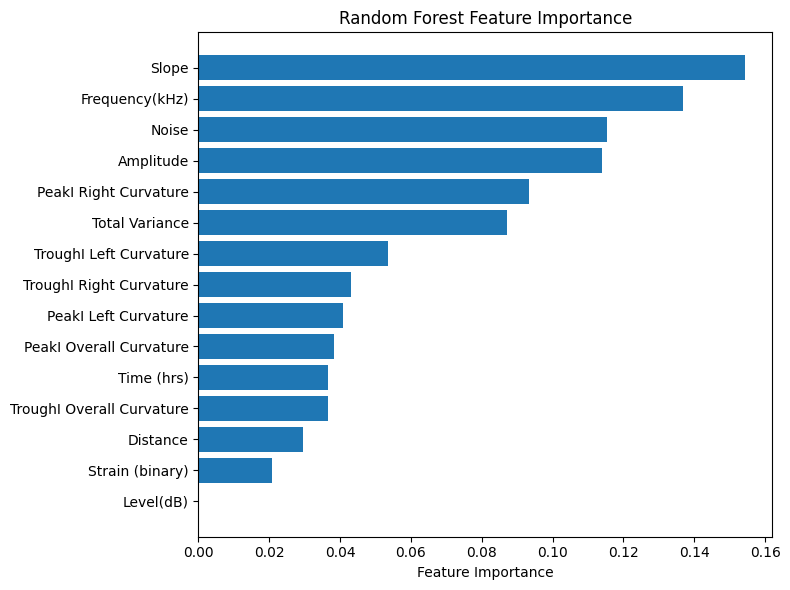

In [19]:
best_rf_model = rf_search.best_estimator_
feature_importance = best_rf_model.named_steps["rf"].feature_importances_
feature_names = best_rf_model.feature_names_in_

importance_df = pd.DataFrame(
    {"Feature": feature_names, "Importance": feature_importance}
).sort_values("Importance", ascending=False)

plt.figure(figsize=(8, 6))
plt.barh(range(len(importance_df)), importance_df["Importance"])
plt.yticks(range(len(importance_df)), importance_df["Feature"])
plt.xlabel("Feature Importance")
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Permutation Importance


Permutation Importance Rankings:
                      Feature  Importance_Mean  Importance_Std
6              Frequency(kHz)         0.296317        0.067816
4                       Noise         0.233750        0.064460
10      PeakI Right Curvature         0.034670        0.020248
5             Strain (binary)         0.033749        0.008688
11     TroughI Left Curvature         0.017384        0.009836
14                 Time (hrs)         0.005622        0.013754
13    TroughI Right Curvature         0.004265        0.004293
9     PeakI Overall Curvature         0.003859        0.006572
7              Total Variance         0.001214        0.013227
3                   Level(dB)         0.000000        0.000000
1                       Slope        -0.001448        0.030595
12  TroughI Overall Curvature        -0.001703        0.004884
8        PeakI Left Curvature        -0.002684        0.007079
2                    Distance        -0.004861        0.002492
0                   A

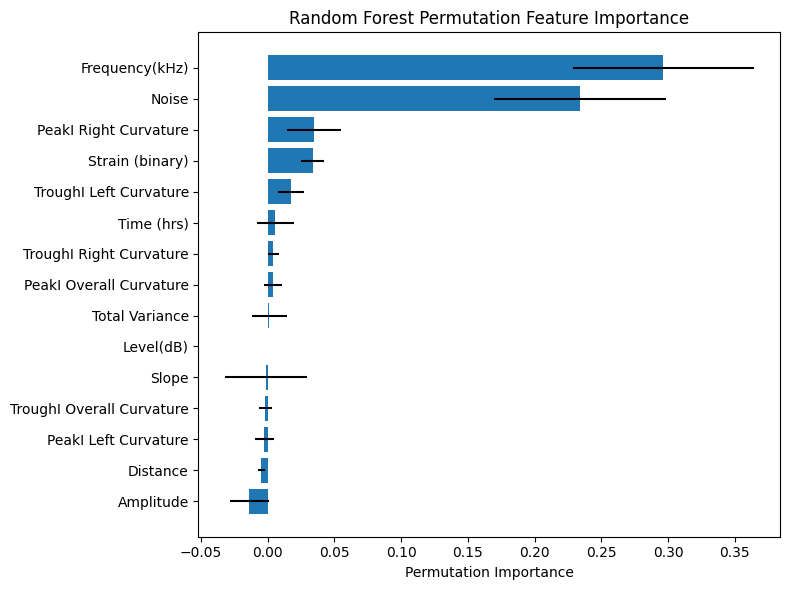

In [20]:
from sklearn.inspection import permutation_importance

perm_importance = permutation_importance(
    best_rf_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="r2",
)
perm_importance_df = pd.DataFrame(
    {
        "Feature": feature_names,
        "Importance_Mean": perm_importance.importances_mean,
        "Importance_Std": perm_importance.importances_std,
    }
).sort_values("Importance_Mean", ascending=False)

print("\nPermutation Importance Rankings:")
print(perm_importance_df)

# Plot permutation importance with error bars
plt.figure(figsize=(8, 6))
plt.barh(
    range(len(perm_importance_df)),
    perm_importance_df["Importance_Mean"],
    xerr=perm_importance_df["Importance_Std"],
)
plt.yticks(range(len(perm_importance_df)), perm_importance_df["Feature"])
plt.xlabel("Permutation Importance")
plt.title("Random Forest Permutation Feature Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# SHAP

[Text(0, 0, 'Level(dB)'), Text(0, 1, 'Distance'), Text(0, 2, 'TroughI Overall Curvature'), Text(0, 3, 'PeakI Overall Curvature'), Text(0, 4, 'TroughI Right Curvature'), Text(0, 5, 'PeakI Left Curvature'), Text(0, 6, 'TroughI Left Curvature'), Text(0, 7, 'Time (hrs)'), Text(0, 8, 'Strain (binary)'), Text(0, 9, 'Total Variance'), Text(0, 10, 'PeakI Right Curvature'), Text(0, 11, 'Amplitude'), Text(0, 12, 'Slope'), Text(0, 13, 'Frequency(kHz)'), Text(0, 14, 'Noise')]


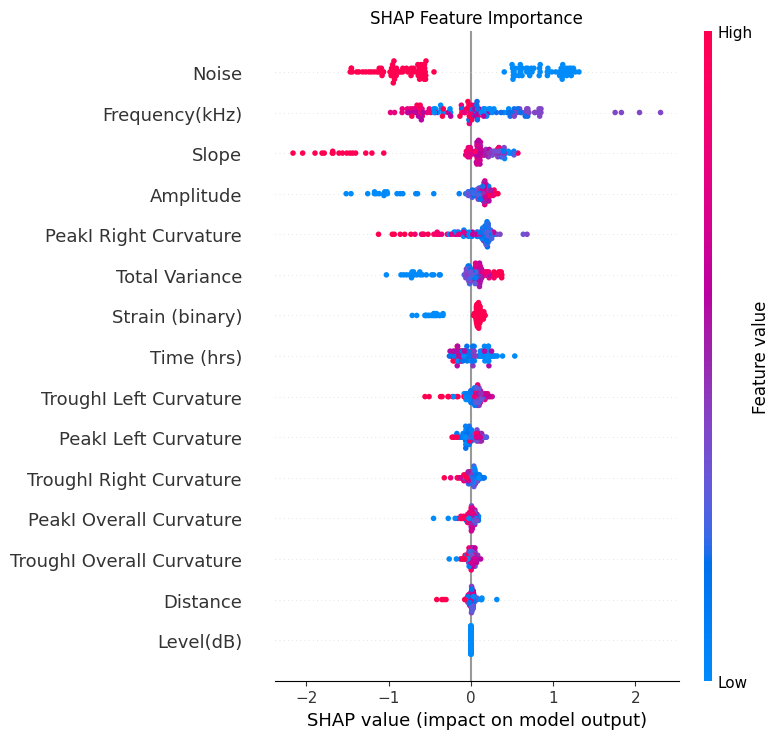

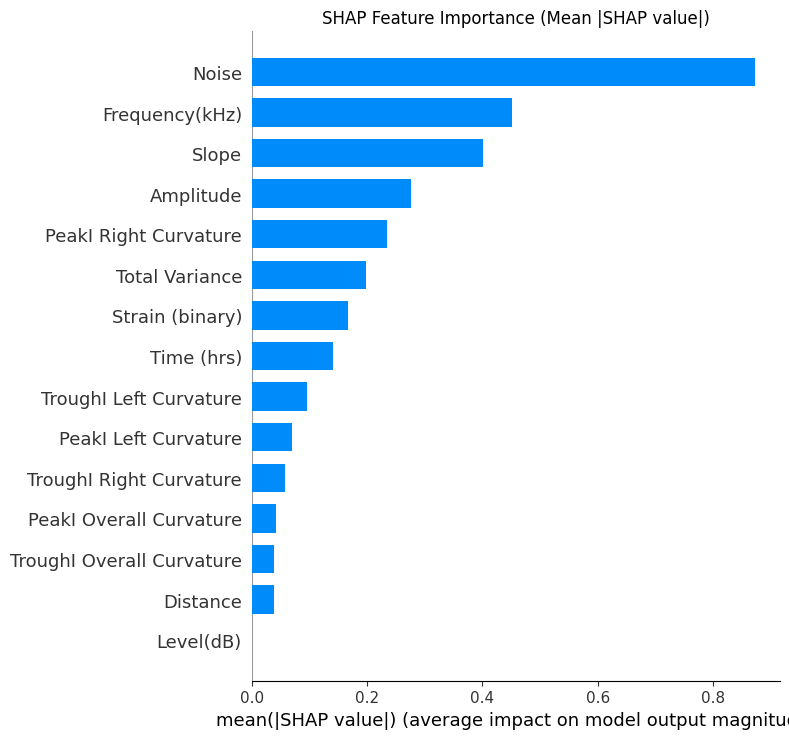

In [21]:
import shap

# Create SHAP explainer
explainer = shap.TreeExplainer(best_rf_model.named_steps["rf"])

# Get preprocessed test data
X_test_preprocessed = best_rf_model.named_steps["preprocessor"].transform(X_test)

# Calculate SHAP values
shap_values = explainer.shap_values(X_test_preprocessed)

# Summary plot
plt.figure(figsize=(5, 4))
shap.summary_plot(
    shap_values, X_test_preprocessed, feature_names=feature_names, show=False
)
plt.title("SHAP Feature Importance")
print(plt.gca().get_yticklabels())
# plt.gca().set_yticklabels(feature_names, rotation=45)
plt.tight_layout()
plt.show()

# Bar plot of mean absolute SHAP values
plt.figure(figsize=(5, 4))
shap.summary_plot(
    shap_values,
    X_test_preprocessed,
    feature_names=feature_names,
    plot_type="bar",
    show=False,
)
plt.title("SHAP Feature Importance (Mean |SHAP value|)")
plt.tight_layout()
plt.show()

In [22]:
shap_interaction_values = explainer.shap_interaction_values(X_test_preprocessed)

In [23]:
def plot_shap_dependence(ft1, ft2):
    top_features = importance_df["Feature"].values
    feature_idx1 = list(feature_names).index(top_features[ft1])
    feature_idx2 = list(feature_names).index(top_features[ft2])

    # Main effects and interaction using shap.dependence_plot
    shap.dependence_plot(
        feature_idx1,
        shap_values,
        X_test_preprocessed,
        feature_names=feature_names,
        show=False,
    )
    plt.title(f"{top_features[ft1]} Main Effect")
    plt.figure(figsize=(3, 3))
    shap.dependence_plot(
        feature_idx2,
        shap_values,
        X_test_preprocessed,
        feature_names=feature_names,
        show=False,
    )
    plt.title(f"{top_features[ft2]} Main Effect")
    plt.figure(figsize=(3, 3))
    shap.dependence_plot(
        (feature_idx1, feature_idx2),
        shap_interaction_values,
        X_test_preprocessed,
        feature_names=feature_names,
        show=False,
        interaction_index=feature_idx2,
    )
    plt.title(f"{top_features[ft1]} x {top_features[ft2]} Interaction")

    plt.tight_layout()
    plt.show()

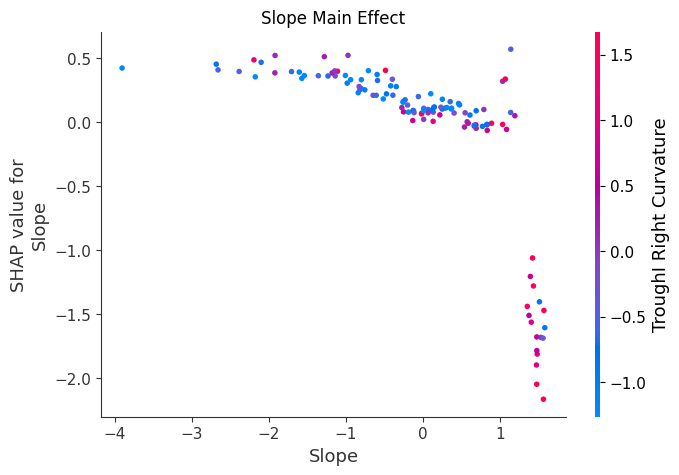

<Figure size 300x300 with 0 Axes>

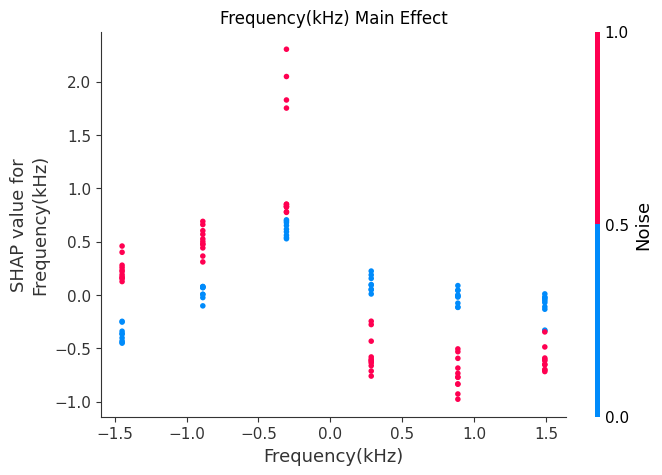

<Figure size 300x300 with 0 Axes>

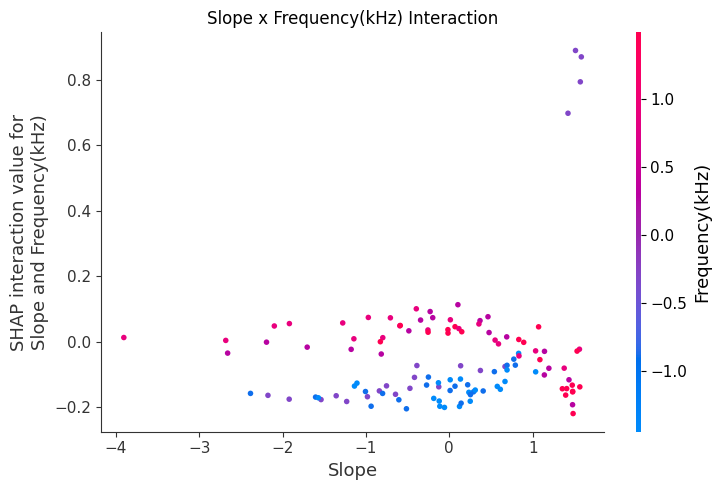

In [24]:
plot_shap_dependence(0, 1)

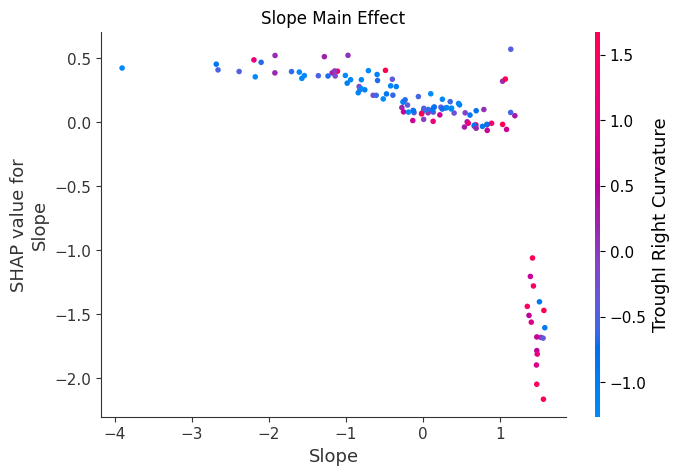

<Figure size 300x300 with 0 Axes>

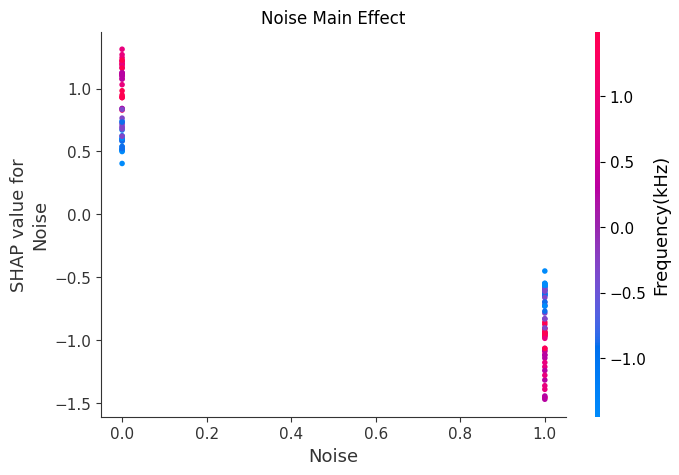

<Figure size 300x300 with 0 Axes>

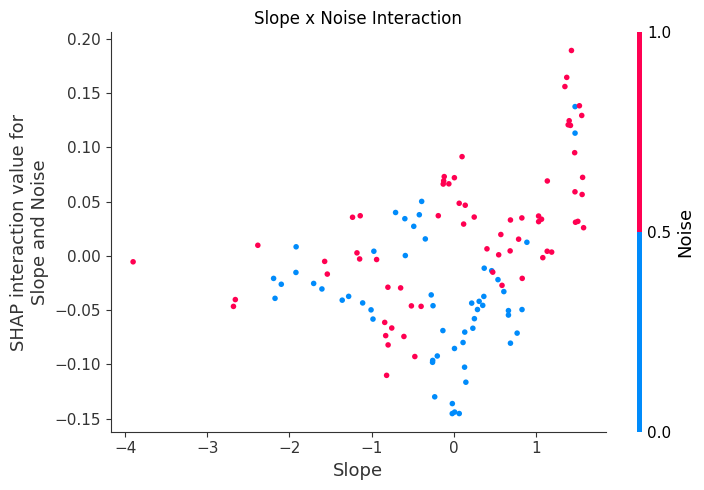

In [25]:
plot_shap_dependence(0, 2)

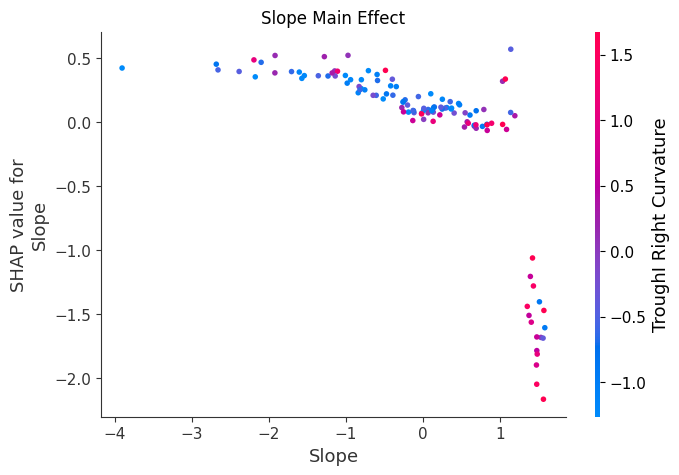

<Figure size 300x300 with 0 Axes>

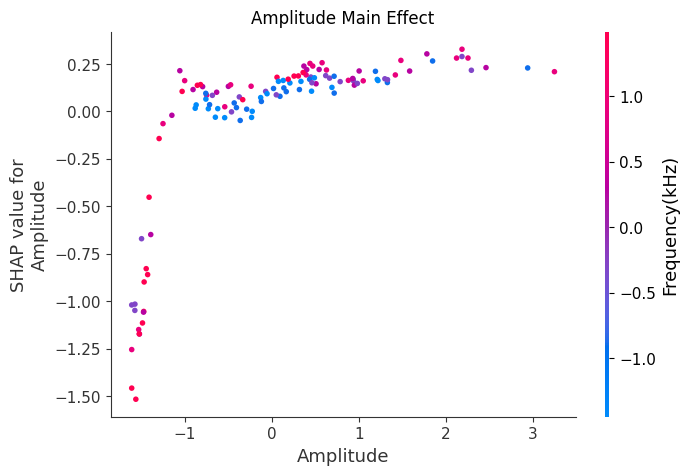

<Figure size 300x300 with 0 Axes>

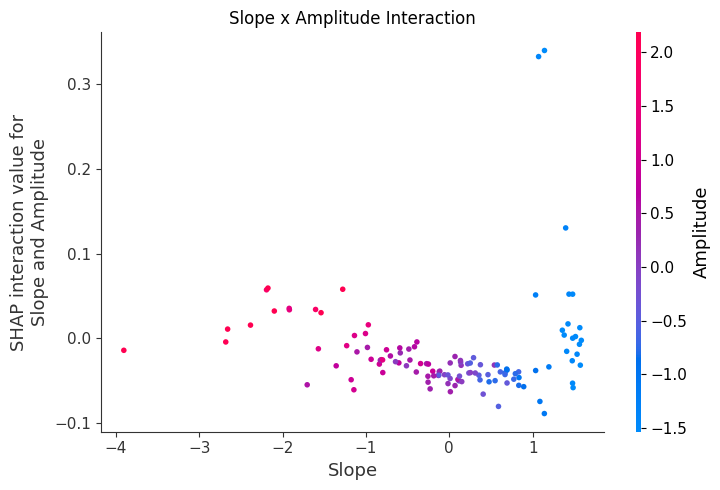

In [26]:
plot_shap_dependence(0, 3)

In [27]:
def plot_results(x, y, alpha=0.2, markersize=5, title="", color=None):
    if color is None:
        color = np.random.rand(
            3,
        )
        while np.mean(color) > 0.6:
            color = np.random.rand(
                3,
            )
    plt.plot(x, y, "o", alpha=alpha, markersize=markersize, color=color)
    plt.plot([5, 20], [5, 20], "k--", alpha=0.5)
    plt.axis("square")
    plt.xticks(np.arange(5, 21, 5))
    plt.yticks(np.arange(5, 21, 5))
    plt.xlim(5, 20)
    plt.ylim(5, 20)
    plt.title(title)
    plt.xlabel("GT # Synapses")
    plt.ylabel("Predicted # Synapses")

In [28]:
def train_plot_result(df, rf_pipeline):
    df = split_by_mouse(df)
    X_train, X_test, y_train, y_test, preprocessor = RF_data_prep(
        df, num_features, cat_features, log_features, minmax_features
    )
    dB_bins = [10, 20, 30, 40, 50, 60, 70, 80]
    plt.figure(figsize=(10, 4))

    color_palette = plt.cm.get_cmap("tab10", len(dB_bins) + 2)
    # iterate over dB levels:
    for dB in dB_bins:
        features = num_features + cat_features + log_features + minmax_features
        data = df[(df["Level(dB)"] >= dB) & (df["Level(dB)"] < dB + 10)]
        X = data[features]
        y = data["SynapsesPerIHC"]
        X_train1, X_test1, y_train1, y_test1 = (
            X[data.DataGroup != "Test"],
            X[data.DataGroup == "Test"],
            y[data.DataGroup != "Test"],
            y[data.DataGroup == "Test"],
        )
        if len(X_train1) > 0 and len(X_test1) > 0:
            rf_pipeline.fit(X_train1, y_train1)
            r2 = rf_pipeline.score(X_test1, y_test1)
            rmse = np.sqrt(np.mean((y_test1 - rf_pipeline.predict(X_test1)) ** 2))
            print(
                f"{dB}-{dB + 5} dB, {len(data)} samples, R2: {r2:.3f}, RMSE: {rmse:.3f}"
            )
            plt.subplot(2, 5, dB // 10)
            plot_results(
                y_test1,
                rf_pipeline.predict(X_test1),
                title=f"{dB}-{dB + 5} dB",
                color=color_palette(dB // 10 - 1),
            )
            # show R2 in lower right corner of plot:
            plt.text(
                19.75,
                5,
                f"R2: {r2:.2f}",
                fontsize=10,
                horizontalalignment="right",
                verticalalignment="bottom",
            )

    # run on all data:
    rf_pipeline.fit(X_train, y_train)
    r2 = rf_pipeline.score(X_test, y_test)
    rmse = np.sqrt(np.mean((y_test - rf_pipeline.predict(X_test)) ** 2))
    print(f"All data, {len(df)} samples, R2: {r2:.3f}, RMSE: {rmse:.3f}")
    plt.subplot(2, 5, 9)
    plot_results(
        y_test,
        rf_pipeline.predict(X_test),
        alpha=0.05,
        title=f"All",
        color=color_palette(-2),
    )
    plt.text(
        19.75,
        5,
        f"R2: {r2:.2f}",
        fontsize=10,
        horizontalalignment="right",
        verticalalignment="bottom",
    )

    test_set = df[df["DataGroup"] == "Test"]
    test_set["RF predictions"] = rf_pipeline.predict(X_test)

    plt.text(
        19.75,
        5,
        f"R2: {r2:.2f}",
        fontsize=10,
        horizontalalignment="right",
        verticalalignment="bottom",
    )

    plt.tight_layout()
    plt.show()

10-15 dB, 542 samples, R2: 0.164, RMSE: 1.801
20-25 dB, 870 samples, R2: 0.458, RMSE: 1.657
30-35 dB, 907 samples, R2: 0.459, RMSE: 1.746
40-45 dB, 802 samples, R2: 0.407, RMSE: 1.950
50-55 dB, 721 samples, R2: 0.457, RMSE: 2.136
60-65 dB, 719 samples, R2: 0.425, RMSE: 2.338
70-75 dB, 724 samples, R2: 0.549, RMSE: 2.486
80-85 dB, 616 samples, R2: 0.549, RMSE: 2.213
All data, 5901 samples, R2: 0.546, RMSE: 1.920


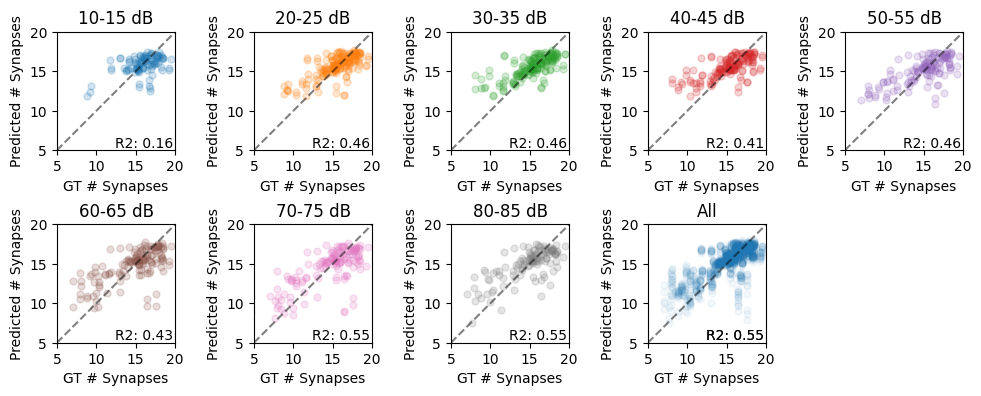

In [29]:
train_plot_result(final_clean_strained, best_rf_model)

Best RF score: 0.696, R2 on test set: 0.488
10-15 dB, 542 samples, R2: 0.145, RMSE: 1.821
20-25 dB, 870 samples, R2: 0.464, RMSE: 1.647
30-35 dB, 907 samples, R2: 0.493, RMSE: 1.691
40-45 dB, 802 samples, R2: 0.440, RMSE: 1.896
50-55 dB, 721 samples, R2: 0.474, RMSE: 2.104
60-65 dB, 719 samples, R2: 0.451, RMSE: 2.285
70-75 dB, 724 samples, R2: 0.540, RMSE: 2.510
80-85 dB, 616 samples, R2: 0.553, RMSE: 2.203
All data, 5901 samples, R2: 0.553, RMSE: 1.906


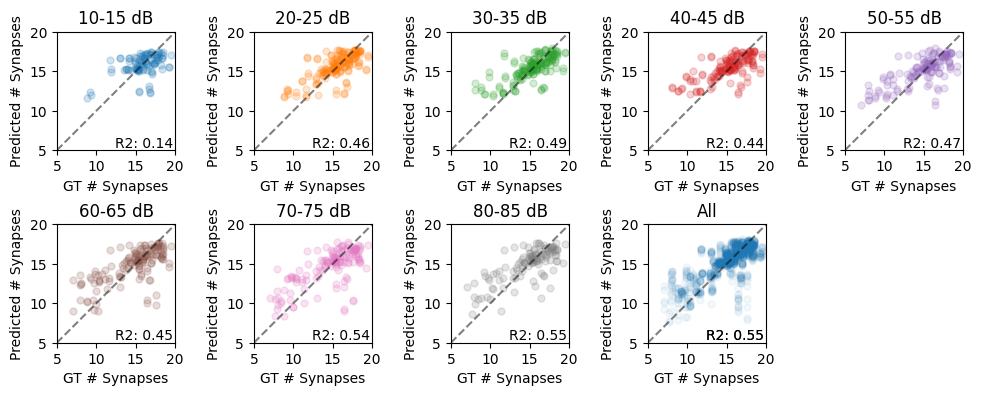

In [30]:
# Deeper trees
rf_pipeline = Pipeline(
    [
        ("preprocessor", preprocessor),
        (
            "rf",
            RandomForestRegressor(
                random_state=1,
                n_estimators=50,
                min_samples_split=30,
                min_samples_leaf=2,
                max_features=0.5,
                max_depth=30,
            ),
        ),
    ]
)
rf_pipeline.fit(X_train, y_train)
r2 = rf_pipeline.score(X_test, y_test)
print(
    f"Best RF score: {rf_pipeline.score(X_train, y_train):.3f}, R2 on test set: {r2:.3f}"
)
train_plot_result(final_clean_strained, rf_pipeline)

In [31]:
from statsmodels.gam.api import GLMGam, BSplines
import statsmodels.api as sm

features = [
    "Frequency",
    "Amplitude",
    "Slope",
    "TotalVariance",
    "Distance",
    "Noise",
    "Time_hrs",
    "PeakILeftCurvature",
    "PeakIOverallCurvature",
    "PeakIRightCurvature",
    "TroughILeftCurvature",
    "TroughIOverallCurvature",
    "TroughIRightCurvature",
]
df_each = 4
degree_each = 3
y = smf_df["SynapsesPerIHC"].values
bs = BSplines(
    smf_df[features], df=[df_each] * len(features), degree=[degree_each] * len(features)
)
gam = GLMGam(y, smoother=bs).fit()
gam.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                      y   No. Observations:                  616
Model:                         GLMGam   Df Residuals:                      579
Model Family:                Gaussian   Df Model:                        36.00
Link Function:               Identity   Scale:                          6.2713
Method:                         PIRLS   Log-Likelihood:                -1420.5
Date:                Sun, 22 Feb 2026   Deviance:                       3631.1
Time:                        18:45:16   Pearson chi2:                 3.63e+03
No. Iterations:                     3   Pseudo R-squ. (CS):             0.5626
Covariance Type:            nonrobust                                         
==============================================================================================
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Frequency_s0                   5.9434      0.865      6.874      0.000       4.249       7.638
Frequency_s1                  -5.5251      0.756     -7.308      0.000      -7.007      -4.043
Frequency_s2                   0.9649      0.378      2.552      0.011       0.224       1.706
Amplitude_s0                  15.8617      2.650      5.986      0.000      10.668      21.055
Amplitude_s1                   0.7814      6.912      0.113      0.910     -12.765      14.328
Amplitude_s2                  12.3051      8.909      1.381      0.167      -5.157      29.767
Slope_s0                      18.0886      2.384      7.586      0.000      13.415      22.762
Slope_s1                       2.8089      2.337      1.202      0.229      -1.771       7.388
Slope_s2                      12.1897      1.042     11.700      0.000      10.148      14.232
TotalVariance_s0              -7.1733      3.979     -1.803      0.071     -14.973       0.626
TotalVariance_s1               7.8316      4.074      1.923      0.055      -0.152      15.815
TotalVariance_s2              -2.9770      8.752     -0.340      0.734     -20.131      14.177
Distance_s0                    7.7937      2.566      3.038      0.002       2.765      12.822
Distance_s1                  -18.5981      2.860     -6.503      0.000     -24.204     -12.993
Distance_s2                    6.4145      1.968      3.260      0.001       2.558      10.271
Noise_s0                   -2.528e-15   3.11e-15     -0.813      0.416   -8.62e-15    3.56e-15
Noise_s1                    8.884e-16   1.09e-14      0.082      0.935   -2.04e-14    2.22e-14
Noise_s2                      -2.4926      0.245    -10.188      0.000      -2.972      -2.013
Time_hrs_s0                   -2.8360      1.096     -2.587      0.010      -4.984      -0.688
Time_hrs_s1                    1.2131      0.925      1.312      0.190      -0.599       3.026
Time_hrs_s2                   -1.3717      0.401     -3.418      0.001      -2.158      -0.585
PeakILeftCurvature_s0          2.5996      1.341      1.938      0.053      -0.029       5.228
PeakILeftCurvature_s1         -1.9940      2.275     -0.877      0.381      -6.452       2.464
PeakILeftCurvature_s2          1.7003      2.526      0.673      0.501      -3.250       6.650
PeakIOverallCurvature_s0      -0.5380      1.256     -0.428      0.668      -2.999       1.923
PeakIOverallCurvature_s1       0.9748      1.591      0.613      0.540      -2.144       4.093
PeakIOverallCurvature_s2      -1.7226      2.048     -0.841      0.400      -5.736       2.291
PeakIRightCurvature_s0        -0.9130      1.491     -0.612      0.540      -3.835       2.009
PeakIRightCurvature_s1        -4.7668      2.316     -2.058      0.040      -9.305      -0.228
PeakIRightCurvature_s2        -4.7052      

In [32]:
def train_plot_result_frequency(df, rf_pipeline):
    df = split_by_mouse(df)
    X_train, X_test, y_train, y_test, preprocessor = RF_data_prep(
        df, num_features, cat_features, log_features, minmax_features
    )
    freqs = sorted(X_train["Frequency(kHz)"].unique())
    plt.figure(figsize=(10, 4))

    color_palette = plt.cm.get_cmap("tab10", len(freqs) + 2)
    # iterate over dB levels:
    for i, frq in zip(range(len(freqs)), freqs):
        features = num_features + cat_features + log_features + minmax_features
        data = df[df["Frequency(kHz)"] == frq]
        X = data[features]
        y = data["SynapsesPerIHC"]
        X_train1, X_test1, y_train1, y_test1 = (
            X[data.DataGroup != "Test"],
            X[data.DataGroup == "Test"],
            y[data.DataGroup != "Test"],
            y[data.DataGroup == "Test"],
        )
        if len(X_train1) > 0 and len(X_test1) > 0:
            rf_pipeline.fit(X_train1, y_train1)
            r2 = rf_pipeline.score(X_test1, y_test1)
            rmse = np.sqrt(np.mean((y_test1 - rf_pipeline.predict(X_test1)) ** 2))
            print(f"{frq}Hz, {len(data)} samples, R2: {r2:.3f}, RMSE: {rmse:.3f}")
            plt.subplot(2, 4, i + 1)
            plot_results(
                y_test1,
                rf_pipeline.predict(X_test1),
                title=f"{frq}Hz",
                color=color_palette(i),
            )
            # show R2 in lower right corner of plot:
            plt.text(
                19.75,
                5,
                f"R2: {r2:.2f}",
                fontsize=10,
                horizontalalignment="right",
                verticalalignment="bottom",
            )

    # run on all data:
    rf_pipeline.fit(X_train, y_train)
    r2 = rf_pipeline.score(X_test, y_test)
    rmse = np.sqrt(np.mean((y_test - rf_pipeline.predict(X_test)) ** 2))
    print(f"All data, {len(df)} samples, R2: {r2:.3f}, RMSE: {rmse:.3f}")
    plt.subplot(2, 4, 7)
    plot_results(
        y_test,
        rf_pipeline.predict(X_test),
        alpha=0.05,
        title=f"All",
        color=color_palette(-2),
    )
    plt.text(
        19.75,
        5,
        f"R2: {r2:.2f}",
        fontsize=10,
        horizontalalignment="right",
        verticalalignment="bottom",
    )

    test_set = df[df["DataGroup"] == "Test"]
    test_set["RF predictions"] = rf_pipeline.predict(X_test)

    plt.text(
        19.75,
        5,
        f"R2: {r2:.2f}",
        fontsize=10,
        horizontalalignment="right",
        verticalalignment="bottom",
    )

    plt.tight_layout()
    plt.show()

8.0Hz, 1043 samples, R2: 0.583, RMSE: 0.882
11.3Hz, 1009 samples, R2: 0.292, RMSE: 0.924
16.0Hz, 979 samples, R2: -0.008, RMSE: 1.472
22.6Hz, 953 samples, R2: 0.549, RMSE: 2.243
32.0Hz, 947 samples, R2: 0.724, RMSE: 1.956
45.2Hz, 970 samples, R2: 0.377, RMSE: 2.855
All data, 5901 samples, R2: 0.546, RMSE: 1.920


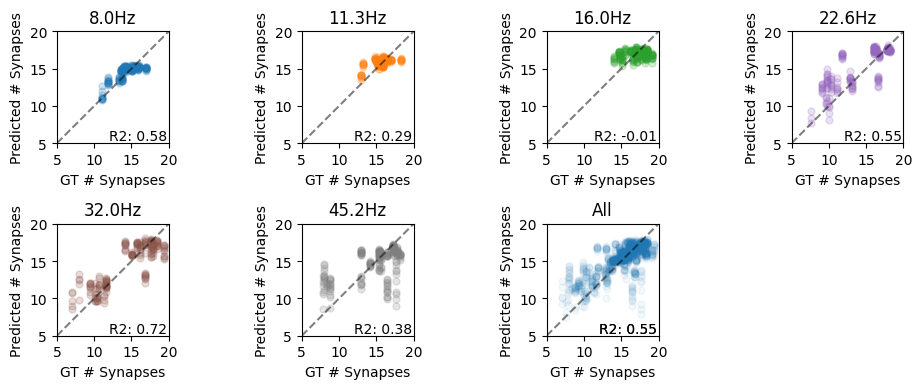

In [33]:
train_plot_result_frequency(final_clean_strained, best_rf_model)

In [ ]:
from sklearn.metrics import r2_score


def train_plot_result_frequency_grouped(df, rf_pipeline):
    df = split_by_mouse(df)
    X_train, X_test, y_train, y_test, preprocessor = RF_data_prep(
        df, num_features, cat_features, log_features, minmax_features
    )
    freqs = sorted(X_train["Frequency(kHz)"].unique())
    plt.figure(figsize=(10, 4))

    color_palette = plt.cm.get_cmap("tab10", len(freqs) + 2)
    # iterate over dB levels:
    for i, frq in zip(range(len(freqs)), freqs):
        features = num_features + cat_features + log_features + minmax_features
        data = df[df["Frequency(kHz)"] == frq]
        X = data[features]
        y = data["SynapsesPerIHC"]
        X_train1, X_test1, y_train1, y_test1 = (
            X[data.DataGroup != "Test"],
            X[data.DataGroup == "Test"],
            y[data.DataGroup != "Test"],
            y[data.DataGroup == "Test"],
        )
        if len(X_train1) > 0 and len(X_test1) > 0:
            rf_pipeline.fit(X_train1, y_train1)
            test = data[data.DataGroup == "Test"].copy()
            test["preds"] = rf_pipeline.predict(X_test1)
            grouped_preds = test.groupby(["Subject", "Frequency(kHz)"]).agg(
                {"SynapsesPerIHC": "mean", "preds": "mean"}
            )
            r2 = r2_score(grouped_preds["SynapsesPerIHC"], grouped_preds["preds"])
            rmse = np.sqrt(
                np.mean((grouped_preds["SynapsesPerIHC"] - grouped_preds["preds"]) ** 2)
            )
            print(f"{frq}Hz, {len(data)} samples, R2: {r2:.3f}, RMSE: {rmse:.3f}")
            plt.subplot(2, 4, i + 1)
            plot_results(
                grouped_preds["SynapsesPerIHC"],
                grouped_preds["preds"],
                title=f"{frq}Hz",
                color=color_palette(i),
                alpha=0.5,
            )
            # show R2 in lower right corner of plot:
            plt.text(
                19.75,
                5,
                f"R2: {r2:.2f}",
                fontsize=10,
                horizontalalignment="right",
                verticalalignment="bottom",
            )

    # run on all data:
    rf_pipeline.fit(X_train, y_train)
    test = df[df.DataGroup == "Test"].copy()
    test["preds"] = rf_pipeline.predicst(X_test)
    grouped_preds = test.groupby(["Subject", "Frequency(kHz)"]).agg(
        {"SynapsesPerIHC": "mean", "preds": "mean"}
    )
    r2 = r2_score(grouped_preds["SynapsesPerIHC"], grouped_preds["preds"])
    rmse = np.sqrt(
        np.mean((grouped_preds["SynapsesPerIHC"] - grouped_preds["preds"]) ** 2)
    )
    print(f"All data, {len(df)} samples, R2: {r2:.3f}, RMSE: {rmse:.3f}")
    plt.subplot(2, 4, 7)
    plot_results(
        grouped_preds["SynapsesPerIHC"],
        grouped_preds["preds"],
        alpha=0.25,
        title=f"All",
        color=color_palette(-2),
    )
    plt.text(
        19.75,
        5,
        f"R2: {r2:.2f}",
        fontsize=10,
        horizontalalignment="right",
        verticalalignment="bottom",
    )

    test_set = df[df["DataGroup"] == "Test"]
    test_set["RF predictions"] = rf_pipeline.predict(X_test)

    plt.text(
        19.75,
        5,
        f"R2: {r2:.2f}",
        fontsize=10,
        horizontalalignment="right",
        verticalalignment="bottom",
    )

    plt.tight_layout()
    plt.show()

8.0Hz, 1043 samples, R2: 0.626, RMSE: 0.812
11.3Hz, 1009 samples, R2: 0.305, RMSE: 0.944
16.0Hz, 979 samples, R2: 0.057, RMSE: 1.424
22.6Hz, 953 samples, R2: 0.626, RMSE: 2.122
32.0Hz, 947 samples, R2: 0.747, RMSE: 2.078
45.2Hz, 970 samples, R2: 0.543, RMSE: 2.985
All data, 5901 samples, R2: 0.649, RMSE: 1.953


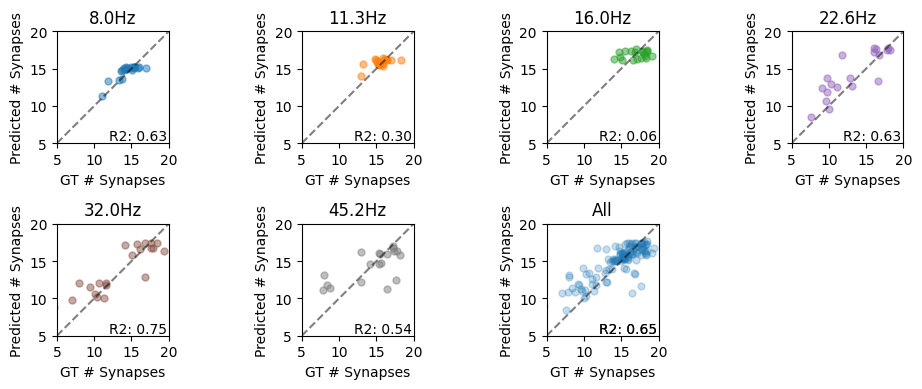

In [35]:
train_plot_result_frequency_grouped(final_clean_strained, best_rf_model)

# XGBoost

In [36]:
from sklearn.model_selection import GridSearchCV
import multiprocessing
import xgboost as xgb

clf_params = {
    "clf__n_estimators": [25, 50, 100, 150, 200, 300],
    "clf__max_depth": [2, 4, 6, 8, 10],
}

clf_pipeline = Pipeline(
    [
        ("preprocessor", preprocessor),
        (
            "clf",
            xgb.XGBRegressor(
                tree_method="hist",
                n_jobs=multiprocessing.cpu_count() // 2,
            ),
        ),
    ]
)

# Use RandomizedSearchCV for efficiency
clf_search = GridSearchCV(
    clf_pipeline,
    clf_params,
    cv=5,
    scoring="r2",
    n_jobs=2,
)
clf_search.fit(X_train, y_train)
print(f"Best XGB params: {clf_search.best_params_}")
r2 = clf_search.score(X_test, y_test)
print(f"Best XGB score: {clf_search.best_score_:.3f}, R2 on test set: {r2:.3f}")
xgb_model = clf_search.best_estimator_

Best XGB params: {'clf__max_depth': 4, 'clf__n_estimators': 25}
Best XGB score: 0.436, R2 on test set: 0.421


8.0Hz, 1043 samples, R2: 0.498, RMSE: 0.968
11.3Hz, 1009 samples, R2: 0.145, RMSE: 1.015
16.0Hz, 979 samples, R2: -0.023, RMSE: 1.484
22.6Hz, 953 samples, R2: 0.460, RMSE: 2.455
32.0Hz, 947 samples, R2: 0.711, RMSE: 2.001
45.2Hz, 970 samples, R2: 0.313, RMSE: 2.998
All data, 5901 samples, R2: 0.548, RMSE: 1.917


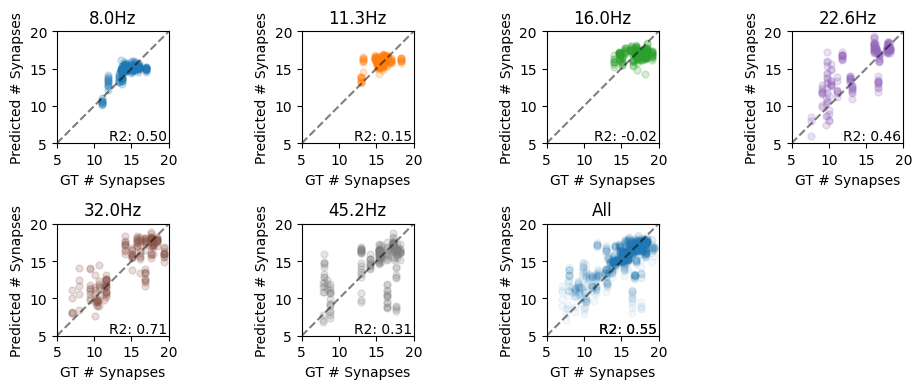

In [37]:
train_plot_result_frequency(final_clean_strained, xgb_model)

8.0Hz, 1043 samples, R2: 0.564, RMSE: 0.877
11.3Hz, 1009 samples, R2: 0.218, RMSE: 1.001
16.0Hz, 979 samples, R2: 0.087, RMSE: 1.401
22.6Hz, 953 samples, R2: 0.591, RMSE: 2.219
32.0Hz, 947 samples, R2: 0.811, RMSE: 1.798
45.2Hz, 970 samples, R2: 0.585, RMSE: 2.843
All data, 5901 samples, R2: 0.663, RMSE: 1.912


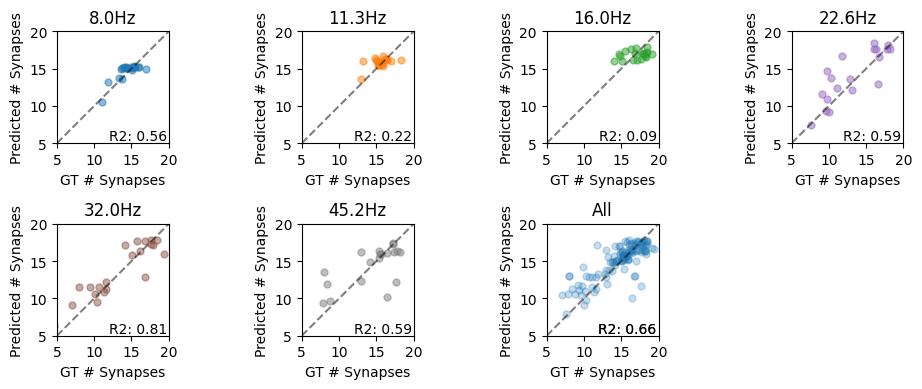

In [39]:
train_plot_result_frequency_grouped(final_clean_strained, xgb_model)